# Dashboard de Comparação de Modelos ASR — VoiceWriter

Compara os modelos ASR do estudo usando as métricas coletadas no **Supabase**
(`sessions`, `transcription_results`, `command_results`), agregando por modelo.

**Três eixos:** qualidade de transcrição (ditado), performance (velocidade) e comandos de voz.

> Requer `.env` na raiz com `SUPABASE_URL` e `SUPABASE_KEY`. Rode a partir da raiz do projeto.


In [1]:
# Setup
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "voice").exists() and (ROOT.parent / "voice").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
%matplotlib inline

from voice.utils.metrics_reader import load_transcriptions, load_commands
print("Setup ok. Raiz:", ROOT)


Setup ok. Raiz: /mnt/316f1a60-da34-40af-9076-4b3ee9fb0ed1/Documents/projects/VoiceWriter


## Sobre escala e interpretação (leia antes dos gráficos)

As métricas aqui têm **naturezas e escalas muito diferentes**, e ignorar isso gera gráficos enganosos. Dois problemas de escala e como este notebook os trata:

1. **Amplitude dentro de uma métrica (ordens de grandeza).** RTF varia de `0.06` a `19.5` (**~300×**) e a latência de `3.5s` a `~1080s`. Num gráfico de barras **linear**, o maior valor esmaga todos os outros até virarem tracinhos. → usamos **escala logarítmica** para RTF e latência.

2. **Unidades incompatíveis entre métricas.** WER é uma proporção (0–1), latência é ms, BLEU é 0–1, sucesso é %. Não dá para colocá-las juntas numa mesma barra. → para a visão consolidada usamos um **heatmap normalizado** (cada métrica reescalada para `[0,1]`, onde `1 = melhor do conjunto`).

Além disso, dois cuidados de **interpretação**:

- **Amostra pequena (n ≈ 5–11 por modelo) com dispersão alta.** A média sozinha mente — um único áudio ruim distorce tudo (ex.: granite tem um run com WER 0.89). Por isso mostramos **boxplots com os pontos individuais**, não só barras de média, e reportamos **mediana** (robusta a outlier) ao lado da média.
- **Cobertura desigual entre backends.** `avg_confidence` só existe para faster-whisper (exige *word timestamps*); `peak_memory`/`startup`/`loading` **não são coletados no modo benchmark**. Não comparamos modelos em métricas que só alguns possuem.


## 1. Carga e preparo dos dados

In [2]:
df_t = load_transcriptions()   # ditado  (transcription_results + sessions)
df_c = load_commands()         # comandos (command_results + sessions)

def clean_model(name):
    """Normaliza o nome do modelo (remove ':' solto e prefixo de organizacao)."""
    if not isinstance(name, str) or not name.strip():
        return "desconhecido"
    name = name.strip().rstrip(":").strip()
    if "/" in name:
        name = name.rsplit("/", 1)[-1]
    return name

def _to01(v):
    if isinstance(v, bool):  return float(v)
    if v in (1, 1.0):        return 1.0
    if v in (0, 0.0):        return 0.0
    if isinstance(v, str):
        s = v.strip().lower()
        if s in ("true","1","t","yes","sim"):  return 1.0
        if s in ("false","0","f","no","nao"):  return 0.0
    return np.nan

_BOOL = ["user_success", "cold_start", "is_benchmark"]

def prepare(df):
    if df.empty: return df
    src = df["model_name"] if "model_name" in df.columns else df.get("model")
    df["model_clean"] = "desconhecido" if src is None else src.map(clean_model)
    for c in _BOOL:
        if c in df.columns:
            df[c] = df[c].map(_to01)
    # latencia em segundos ajuda a leitura (valores chegam a ~1e6 ms)
    if "inference_latency_ms" in df.columns:
        df["inference_latency_s"] = pd.to_numeric(df["inference_latency_ms"], errors="coerce") / 1000.0
    return df

df_t, df_c = prepare(df_t), prepare(df_c)

# Foco do estudo: benchmark com referencia (WER objetivo)
b = df_t[df_t.get("is_benchmark") == 1] if "is_benchmark" in df_t.columns else df_t
# ordem canonica dos modelos = do melhor (menor) WER mediano ao pior
ORDER = b.groupby("model_clean")["wer"].median().sort_values().index.tolist()
print(f"Ditado benchmark: {len(b)} linhas | {b['model_clean'].nunique()} modelos")
print("n por modelo:"); print(b["model_clean"].value_counts().reindex(ORDER).to_string())


Ditado benchmark: 75 linhas | 10 modelos
n por modelo:
model_clean
parakeet-tdt-0.6b-v3             11
faster-whisper:large              5
faster-whisper:turbo              5
canary-1b-v2                      5
Voxtral-Mini-4B-Realtime-2602     9
faster-whisper:medium             5
faster-whisper:small             10
granite-4.0-1b-speech            10
faster-whisper:base               5
faster-whisper:tiny              10


In [3]:
# Helpers de visualizacao
GOOD, WARN, BAD = "#4C72B0", "#DD8452", "#C44E52"

def hbar(series, title, xlabel, better="low", log=False, refs=None, unit=""):
    """Barras horizontais ordenadas (melhor no topo); log opcional; linhas de referencia."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        print("sem dados:", title); return
    s = s.sort_values(ascending=(better == "high"))   # melhor termina no topo do barh
    fig, ax = plt.subplots(figsize=(10, 0.55 * len(s) + 1.5))
    ax.barh(s.index, s.values, color=GOOD, edgecolor="black", linewidth=0.4)
    if log:
        ax.set_xscale("log")
    for y, v in enumerate(s.values):
        ax.text(v, y, f" {v:.3g}{unit}", va="center", ha="left", fontsize=10)
    for ref, lab, col in (refs or []):
        ax.axvline(ref, ls="--", lw=1.5, color=col, label=lab)
    if refs: ax.legend(fontsize=10)
    ax.set_title(title); ax.set_xlabel(xlabel + (" (escala log)" if log else ""))
    ax.margins(x=0.12)
    plt.tight_layout(); plt.show()

def box_by_model(df, col, title, xlabel, order=None, log=False, refs=None):
    """Boxplot horizontal por modelo + pontos individuais (mostra dispersao e outliers)."""
    d = df[["model_clean", col]].copy()
    d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna(subset=[col])
    if d.empty:
        print("sem dados:", title); return
    order = [m for m in (order or []) if m in d["model_clean"].unique()] or \
            d.groupby("model_clean")[col].median().sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(11, 0.6 * len(order) + 1.5))
    sns.boxplot(data=d, y="model_clean", x=col, order=order, ax=ax,
                color="#B9C7DE", fliersize=0, width=0.6)
    sns.stripplot(data=d, y="model_clean", x=col, order=order, ax=ax,
                  color="#22364F", size=6, alpha=0.7, jitter=0.15)
    if log: ax.set_xscale("log")
    for ref, lab, col_ in (refs or []):
        ax.axvline(ref, ls="--", lw=1.5, color=col_, label=lab)
    if refs: ax.legend(fontsize=10)
    ax.set_title(title); ax.set_xlabel(xlabel + (" (escala log)" if log else "")); ax.set_ylabel("")
    plt.tight_layout(); plt.show()


## 2. Qualidade da transcrição (ditado)

Comparação contra a referência exata (`is_benchmark = True`). **Menor = melhor**, exceto BLEU.

**Como cada métrica é calculada** (implementação em `voice/utils/asr_metrics.py`):

| Métrica | Fórmula | O que mede |
|---|---|---|
| **WER** (Word Error Rate) | $\dfrac{S + D + I}{N}$ — distância de Levenshtein em **palavras** sobre $N$ = nº de palavras da referência | Taxa de erro por palavra. Pode passar de 1.0 se o modelo inventa muito. |
| **CER** (Character Error Rate) | $\dfrac{\text{Levenshtein}_{\text{char}}(\text{ref},\text{hyp})}{\lvert\text{ref}\rvert}$ | Erro por caractere — mais sensível a acertos parciais (acentos, plurais). |
| **WER normalizado** | WER após *lowercase* + remoção de pontuação | Comparação justa entre modelos que pontuam de formas diferentes. |
| **Breakdown S / D / I** | cada taxa = (substituições \| deleções \| inserções) / $N$, obtidas pelo *traceback* da matriz de programação dinâmica | **Como** o modelo erra (ver abaixo). |
| **BLEU** | precisão de n-gramas com *smoothing* (NLTK, method 1). **Maior = melhor** (1.0 = perfeito) | Fluência/qualidade global da frase, complementa o WER. |

**Lendo o breakdown** — o tipo de erro aponta a causa:
- **Substituições** altas → troca palavras (`casa`→`caça`): problema de **vocabulário/acústica**.
- **Deleções** altas → perde palavras: problema de **VAD/segmentação** (corta áudio).
- **Inserções** altas → inventa palavras: **alucinação** / ruído de fundo.


In [4]:
quality = ["wer", "cer", "wer_normalized",
           "wer_substitutions", "wer_deletions", "wer_insertions", "bleu_score"]
present = [c for c in quality if c in b.columns]
q = b.groupby("model_clean")[present].agg(["median", "mean"])
q.insert(0, ("n", ""), b.groupby("model_clean").size())
q = q.reindex(ORDER)
q.round(4)


n     wer             cer         wer_normalized         wer_substitutions         wer_deletions         wer_insertions         bleu_score        
                                   median    mean  median    mean         median    mean            median    mean        median    mean         median    mean     median    mean
model_clean                                                                                                                                                                       
parakeet-tdt-0.6b-v3           11  0.0495  0.1013  0.0148  0.0563         0.0495  0.1013            0.0463  0.0566        0.0099  0.0270         0.0099  0.0176     0.8856  0.8153
faster-whisper:large            5  0.0630  0.0858  0.0297  0.0609         0.0630  0.0858            0.0556  0.0493        0.0236  0.0275         0.0099  0.0090     0.8496  0.8349
faster-whisper:turbo            5  0.0709  0.0947  0.0328  0.0654         0.0709  0.0947            0.0472  0.0577        0.0157  0.0223         0.0172  0.0145     0.8391  0.8215
canary-1b-v2                    5  0.1024  0.1117  0.0422  0.0718         0.1024  0.1117            0.0787  0.0735        0.0157  0.0279         0.0079  0.0103     0.7821  0.7937
Voxtral-Mini-4B-Realtime-2602   9  0.1024  0.0954  0.0516  0.0610         0.1024  0.0954            0.0630  0.0529        0.0236  0.0258         0.0157  0.0167     0.7868  0.8195
faster-whisper:medium           5  0.1204  0.1067  0.0640  0.0735         0.1204  0.1067            0.0630  0.0651        0.0394  0.0344         0.0089  0.0072     0.7651  0.7952
faster-whisper:small           10  0.2241  0.1840  0.0608  0.0867         0.2241  0.1840            0.1102  0.1164        0.0157  0.0243         0.0357  0.0433     0.6648  0.7027
granite-4.0-1b-speech          10  0.2679  0.3621  0.2009  0.2428         0.2679  0.3621            0.1696  0.1943        0.0370  0.0842         0.0714  0.0836     0.6115  0.5321
faster-whisper:base             5  0.2685  0.2775  0.1100  0.1296         0.2685  0.2775            0.1810  0.1895        0.0278  0.0355         0.0603  0.0525     0.5495  0.5586
faster-whisper:tiny            10  0.4554  0.4391  0.2250  0.1967         0.4554  0.4391            0.3125  0.3076        0.0345  0.0314         0.1188  0.1000     0.3765  0.3883

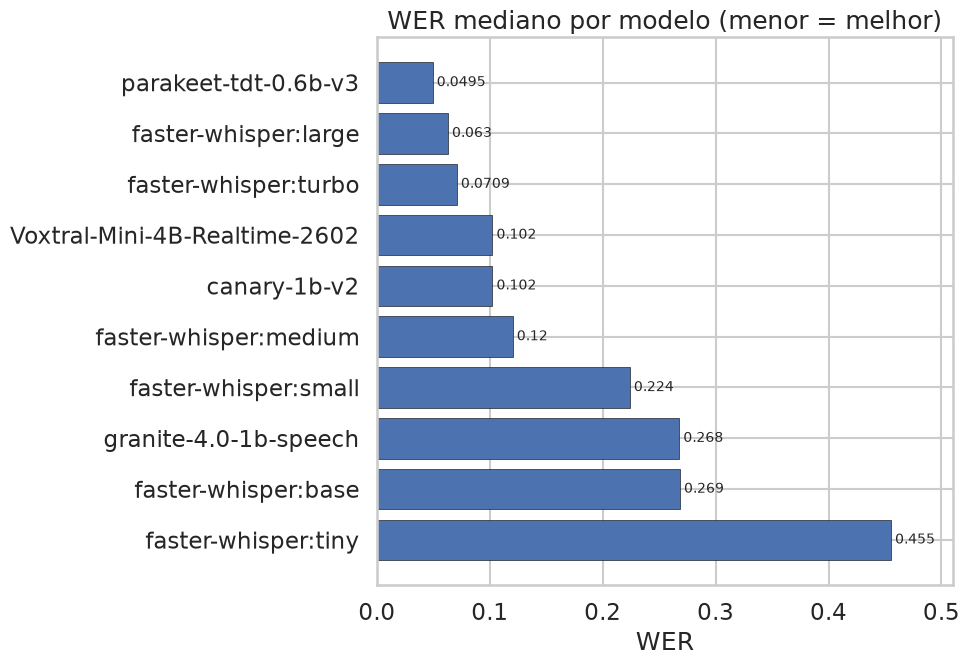

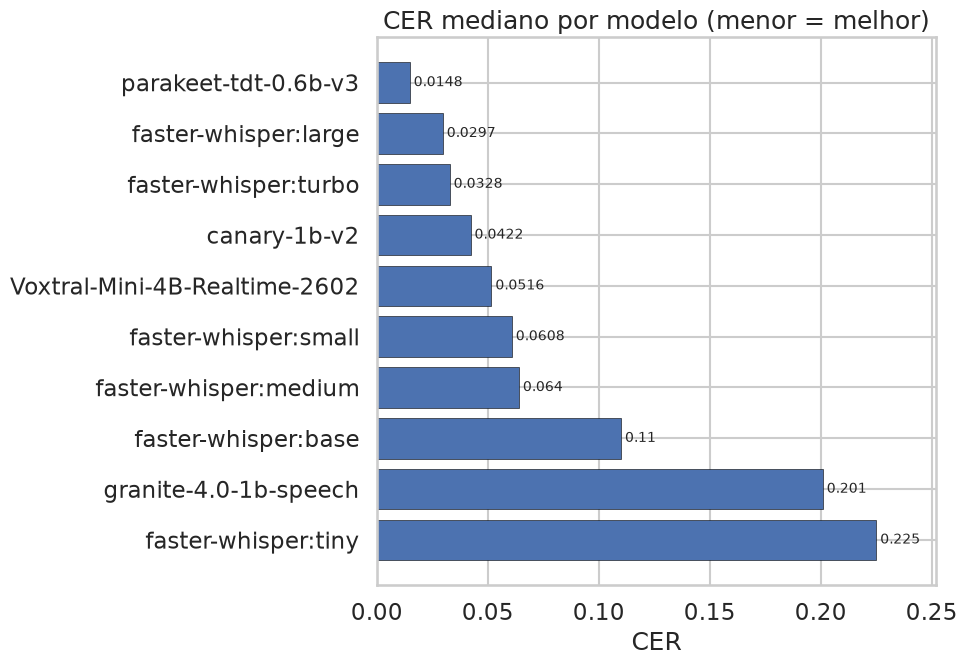

In [5]:
# WER e CER: barras horizontais ordenadas (linear ja serve, sao proporcoes 0-1)
qmed = b.groupby("model_clean")[present].median().reindex(ORDER)
hbar(qmed["wer"], "WER mediano por modelo (menor = melhor)", "WER", better="low")
hbar(qmed["cer"], "CER mediano por modelo (menor = melhor)", "CER", better="low")


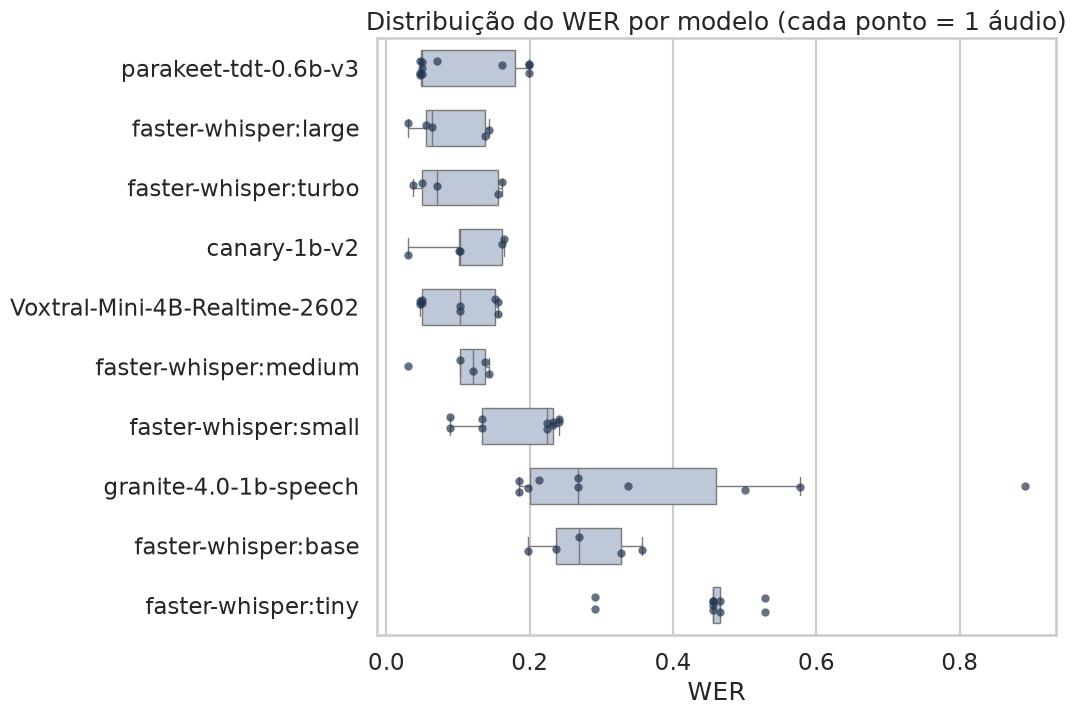

In [6]:
# Distribuicao do WER: revela dispersao e outliers que a media esconde (n pequeno!)
box_by_model(b, "wer", "Distribuição do WER por modelo (cada ponto = 1 áudio)",
             "WER", order=ORDER)


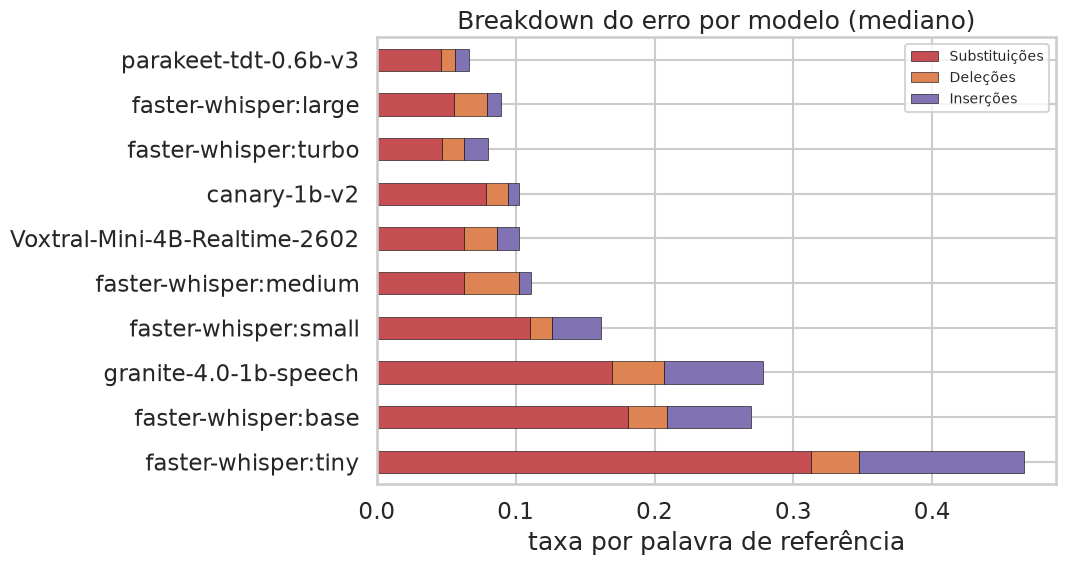

In [7]:
# Breakdown S/D/I empilhado (horizontal, ordenado por WER)
bd = [c for c in ["wer_substitutions","wer_deletions","wer_insertions"] if c in qmed.columns]
if bd:
    ax = qmed[bd].loc[ORDER].plot(kind="barh", stacked=True, figsize=(11, 6),
        color=["#C44E52","#DD8452","#8172B3"], edgecolor="black", linewidth=0.4)
    ax.set_title("Breakdown do erro por modelo (mediano)")
    ax.set_xlabel("taxa por palavra de referência"); ax.set_ylabel("")
    ax.legend(["Substituições","Deleções","Inserções"], fontsize=10)
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()


## 3. Performance (velocidade)

**Como é calculado:**

- **RTF** (Real-Time Factor) $= \dfrac{\text{latência de inferência}}{\text{duração do áudio}}$. **RTF < 1** = mais rápido que tempo real; **alvo do estudo: RTF < 0.3**. RTF = 10 significa 10× mais lento que o áudio.
- **Latência de inferência** = tempo de parede do `model.transcribe()` (ms). Convertida para **segundos** aqui pela magnitude.

> ⚠️ **Escala log obrigatória:** RTF vai de `0.06` a `~19.5` e a latência de `~3.5s` a `~1080s`. Em escala linear um único modelo achata todos os outros.
>
> ⚠️ **Não coletados no benchmark:** `startup_latency_ms`, `loading_model_time` e `peak_memory_mb` chegam **100% nulos** neste modo (o pipeline `run_benchmark_transcription` não os preenche) — por isso não têm gráfico. Ficam disponíveis apenas no uso orgânico do app.


In [8]:
perf = [c for c in ["rtf","inference_latency_s"] if c in b.columns]
pmed  = b.groupby("model_clean")[perf].median().reindex(ORDER)
pstat = b.groupby("model_clean")[perf].agg(["median","mean","max"]).reindex(ORDER)
print("Performance (mediana é robusta a outliers; veja o gap median vs max):")
pstat.round(2)


Performance (mediana é robusta a outliers; veja o gap median vs max):


rtf               inference_latency_s                 
                              median   mean    max              median    mean      max
model_clean                                                                            
parakeet-tdt-0.6b-v3            0.09   0.09   0.13                4.88    4.77     6.59
faster-whisper:large            0.44   0.46   0.52               23.26   24.57    28.28
faster-whisper:turbo            0.10   0.10   0.12                5.20    5.26     5.95
canary-1b-v2                    0.20   0.33   0.84               11.15   17.30    43.00
Voxtral-Mini-4B-Realtime-2602  11.70  12.97  19.50              586.40  692.72  1080.72
faster-whisper:medium           0.33   0.34   0.39               17.18   17.90    21.52
faster-whisper:small            0.18   0.19   0.22                9.47    9.82    11.94
granite-4.0-1b-speech           0.90   0.92   1.28               46.91   48.92    69.94
faster-whisper:base             0.11   0.12   0.14                6.14    6.23     7.04
faster-whisper:tiny             0.09   0.09   0.11                4.60    4.65     5.40

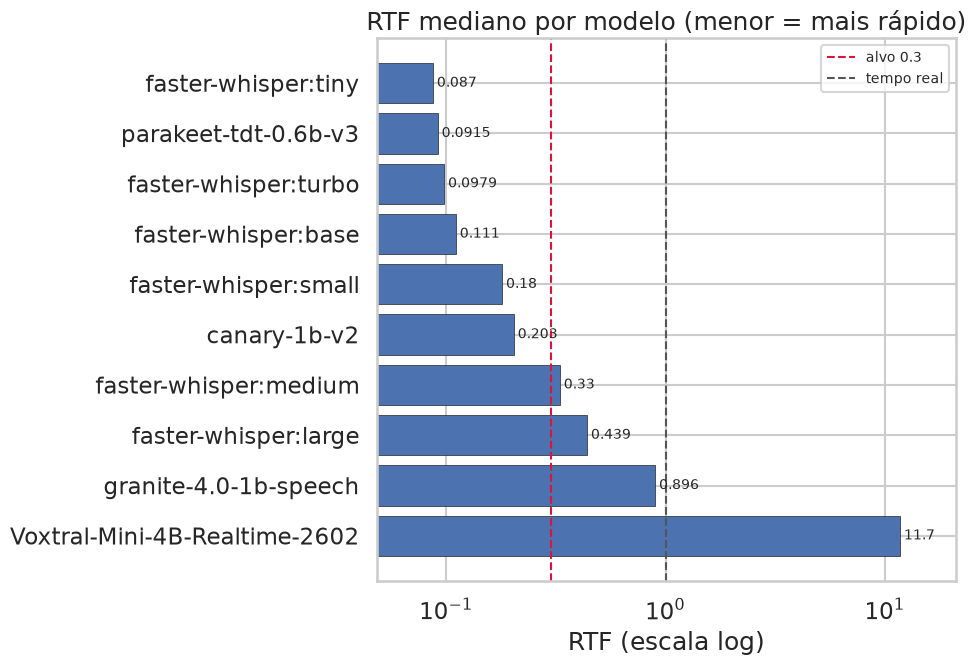

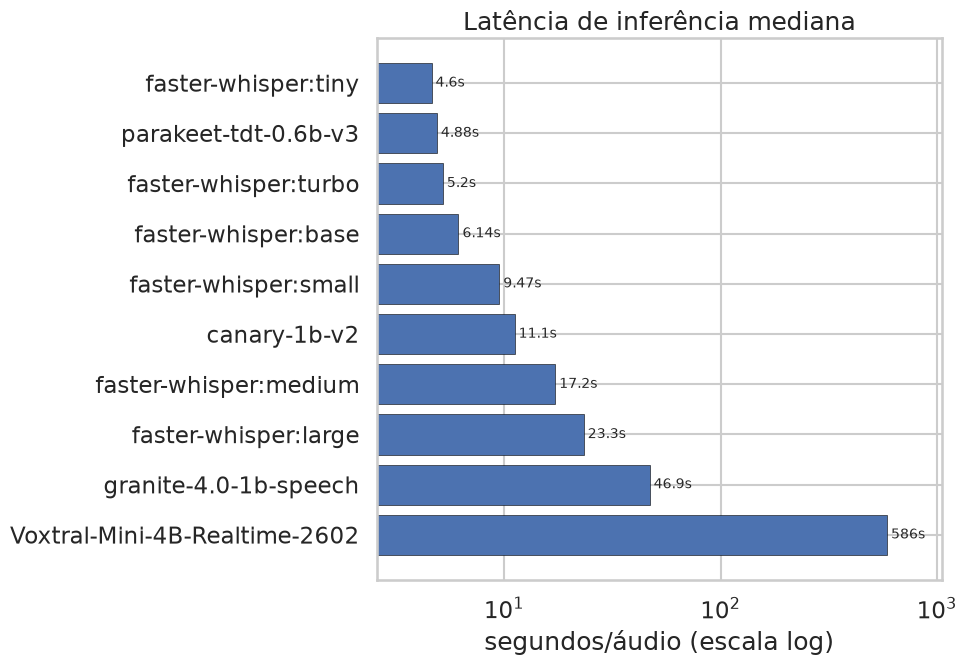

In [9]:
rtf_refs = [(0.3, "alvo 0.3", "crimson"), (1.0, "tempo real", "#555555")]
hbar(pmed["rtf"], "RTF mediano por modelo (menor = mais rápido)", "RTF",
     better="low", log=True, refs=rtf_refs)
if "inference_latency_s" in pmed.columns:
    hbar(pmed["inference_latency_s"], "Latência de inferência mediana", "segundos/áudio",
         better="low", log=True, unit="s")


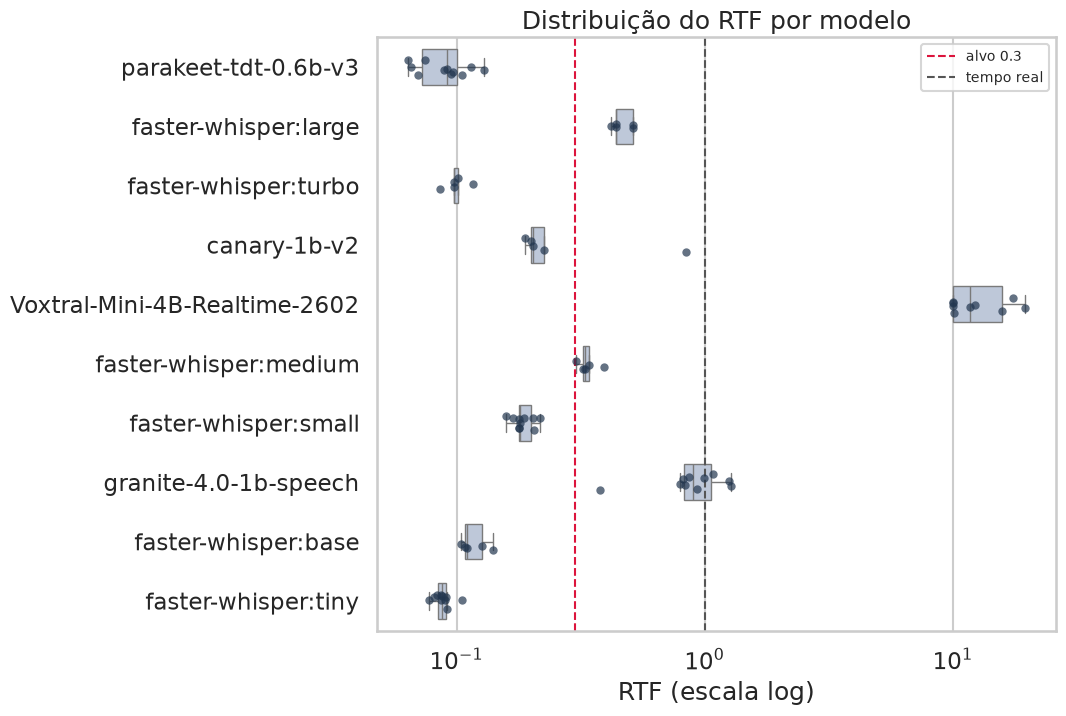

In [10]:
# Distribuicao do RTF em log: o outlier (Voxtral ~10x) aparece sem esconder o resto
box_by_model(b, "rtf", "Distribuição do RTF por modelo", "RTF", order=ORDER,
             log=True, refs=rtf_refs)


## 4. Trade-off velocidade × qualidade

O gráfico mais importante da comparação: cada modelo é um ponto em **(RTF, WER)**.
O **canto inferior-esquerdo é o ideal** (rápido *e* preciso). Modelos que ninguém supera
em ambos os eixos formam a **fronteira de Pareto** — são as escolhas racionais; o resto é dominado.

Eixo RTF em **log** (a amplitude é enorme). A linha `RTF = 1` separa "mais rápido que tempo real"
de "mais lento que o áudio".


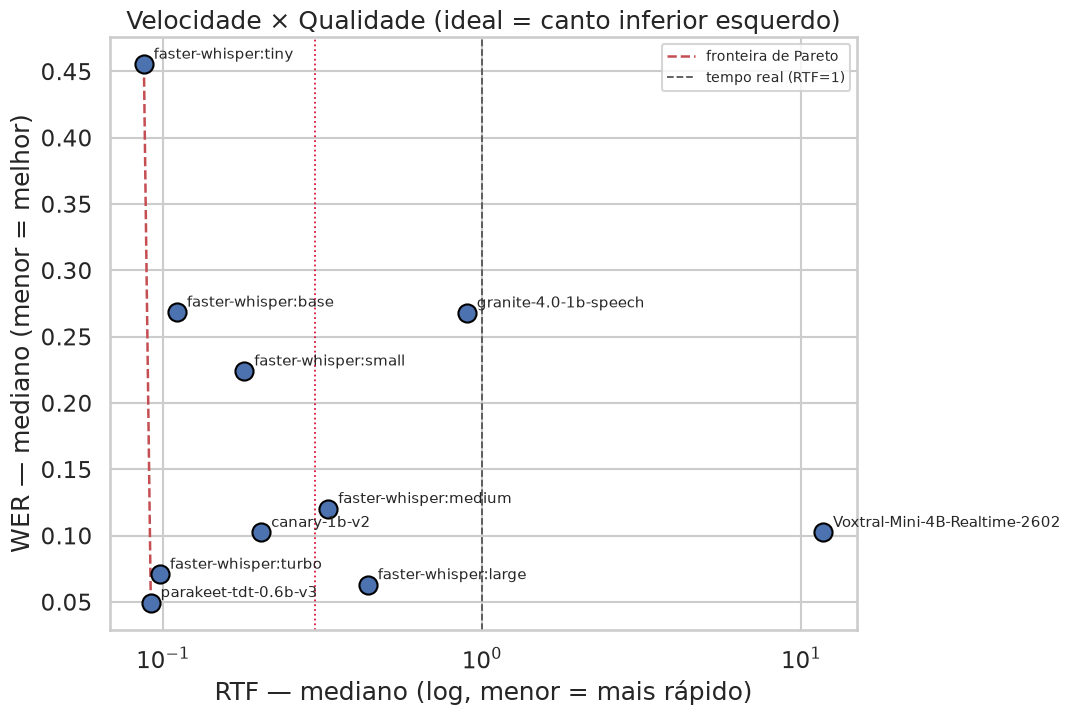

In [11]:
tr = pd.DataFrame({
    "rtf": b.groupby("model_clean")["rtf"].median(),
    "wer": b.groupby("model_clean")["wer"].median(),
}).reindex(ORDER).dropna()

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.scatter(tr["rtf"], tr["wer"], s=170, color=GOOD, edgecolor="black", zorder=3)
for name, r in tr.iterrows():
    ax.annotate(name, (r["rtf"], r["wer"]), fontsize=10.5,
                xytext=(7, 4), textcoords="offset points")
# fronteira de Pareto (menor rtf e menor wer)
pareto, best_wer = [], np.inf
for name, r in tr.sort_values("rtf").iterrows():
    if r["wer"] <= best_wer:
        pareto.append((r["rtf"], r["wer"])); best_wer = r["wer"]
if pareto:
    px, py = zip(*pareto)
    ax.plot(px, py, "--", color=BAD, lw=1.8, zorder=2, label="fronteira de Pareto")
ax.axvline(0.3, ls=":", color="crimson", lw=1.3)
ax.axvline(1.0, ls="--", color="#555555", lw=1.3, label="tempo real (RTF=1)")
ax.set_xscale("log")
ax.set_xlabel("RTF — mediano (log, menor = mais rápido)")
ax.set_ylabel("WER — mediano (menor = melhor)")
ax.set_title("Velocidade × Qualidade (ideal = canto inferior esquerdo)")
ax.legend(fontsize=10); plt.tight_layout(); plt.show()


### Confiança média (`avg_confidence`) — só faster-whisper

$\text{avg\_confidence}$ = média da probabilidade por palavra reportada pelo modelo
(exige *word timestamps*). **Só o backend faster-whisper fornece** — Voxtral, Canary,
Parakeet e Granite retornam vazio. Portanto **não é uma métrica de comparação entre
backends**, apenas entre os tamanhos do Whisper.


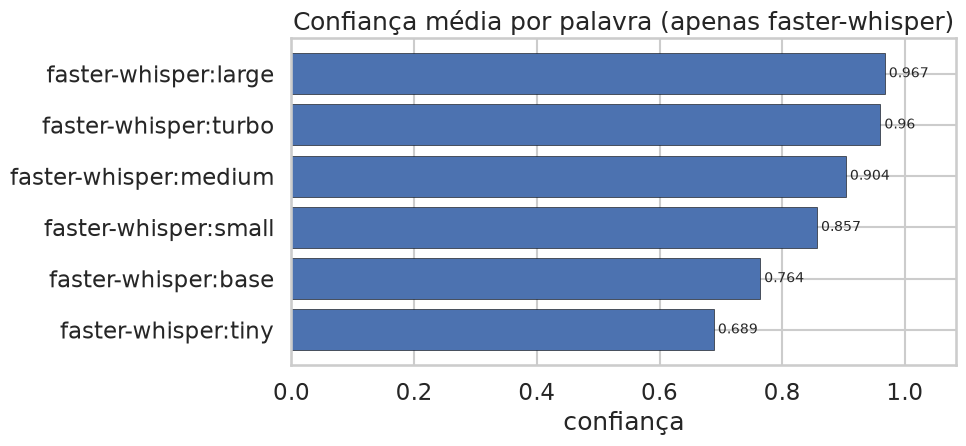

Backends sem confiança (esperado): ['Voxtral-Mini-4B-Realtime-2602', 'canary-1b-v2', 'granite-4.0-1b-speech', 'parakeet-tdt-0.6b-v3']


In [12]:
if "avg_confidence" in b.columns:
    conf = b.dropna(subset=["avg_confidence"])
    conf = conf[pd.to_numeric(conf["avg_confidence"], errors="coerce").notna()]
    if not conf.empty:
        c = conf.groupby("model_clean")["avg_confidence"].median().sort_values(ascending=False)
        hbar(c, "Confiança média por palavra (apenas faster-whisper)", "confiança",
             better="high")
        print("Backends sem confiança (esperado):",
              sorted(set(ORDER) - set(c.index)))


## 5. Comandos de voz

Modo comando: o usuário fala um comando e confirma se foi executado corretamente
(`user_success`, feedback explícito). Métricas:

- **Taxa de sucesso** $= \dfrac{\#\,\text{sucessos}}{\#\,\text{comandos}}$ — **maior = melhor**.
- **Latência** de inferência (segundos), mesma definição do ditado.


,n,success_rate,latency_s
model_clean,,,
canary-v2,43,0.953,3.822
faster-whisper:large,20,0.850,2.182
Voxtral-Mini-4B-Realtime-2602,9,0.778,61.183
parakeet-tdt-0.6b-v3,22,0.773,3.096
faster-whisper:turbo,20,0.750,1.337
faster-whisper:small,41,0.595,1.068
faster-whisper:medium,21,0.571,1.797
granite-4.0-1b-speech,50,0.540,2.147
canary-1b-v2,20,0.400,3.804


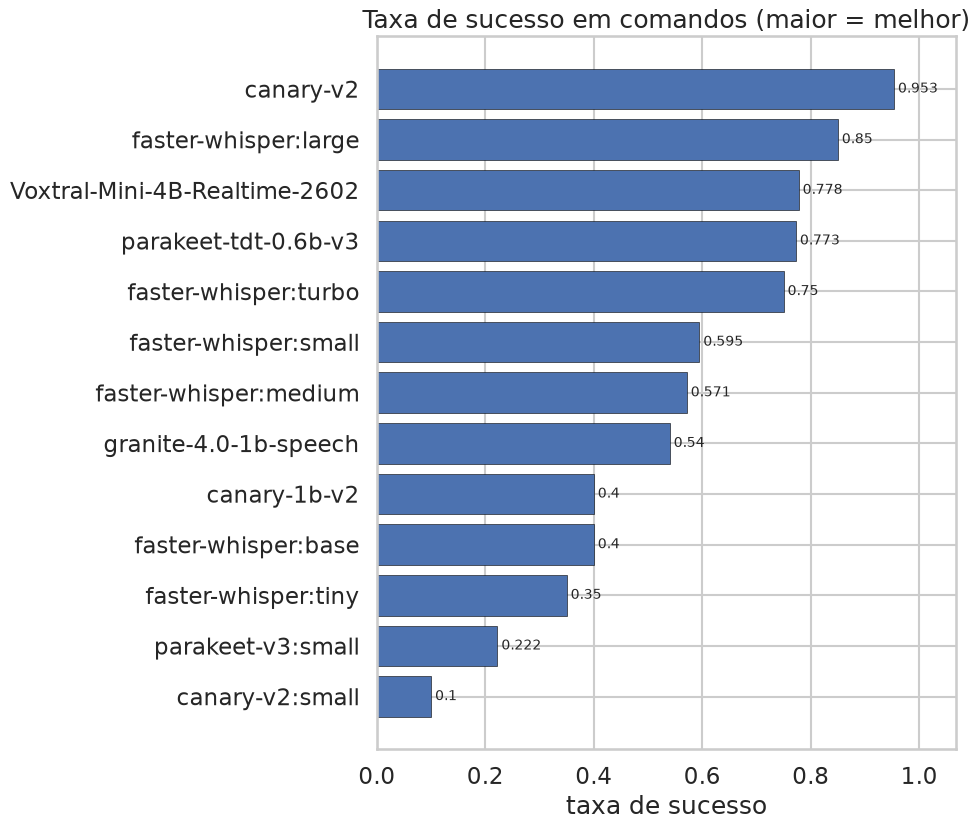

In [13]:
if not df_c.empty:
    grp = df_c.groupby("model_clean")
    cmd = pd.DataFrame({"n": grp.size()})
    if "user_success" in df_c.columns:
        cmd["success_rate"] = grp["user_success"].mean()
    if "inference_latency_s" in df_c.columns:
        cmd["latency_s"] = grp["inference_latency_s"].median()
    cmd = cmd.sort_values("success_rate", ascending=False)
    display(cmd.round(3))
    if "success_rate" in cmd.columns:
        hbar(cmd["success_rate"], "Taxa de sucesso em comandos (maior = melhor)",
             "taxa de sucesso", better="high")
else:
    print("Sem dados de comandos.")


## 6. Comparação consolidada (heatmap normalizado)

Para comparar métricas de **unidades incompatíveis** numa só figura, cada coluna é
**reescalada para `[0,1]`** com min-max, e **orientada para que `1 = melhor` do conjunto**
(invertendo WER, CER, RTF e latência, onde menor é melhor):

$$\text{score} = \begin{cases}\dfrac{v - \min}{\max - \min} & \text{se maior é melhor (BLEU, sucesso)}\\[2ex]\dfrac{\max - v}{\max - \min} & \text{se menor é melhor (WER, CER, RTF, latência)}\end{cases}$$

A **cor** mostra o score relativo (verde = melhor do grupo, vermelho = pior); o **número**
em cada célula é o **valor bruto real** (na unidade da métrica). Usamos a **mediana** por
modelo (robusta a outliers). Normalização é **relativa ao conjunto** — verde não significa
"bom em absoluto", só "o melhor entre estes modelos".


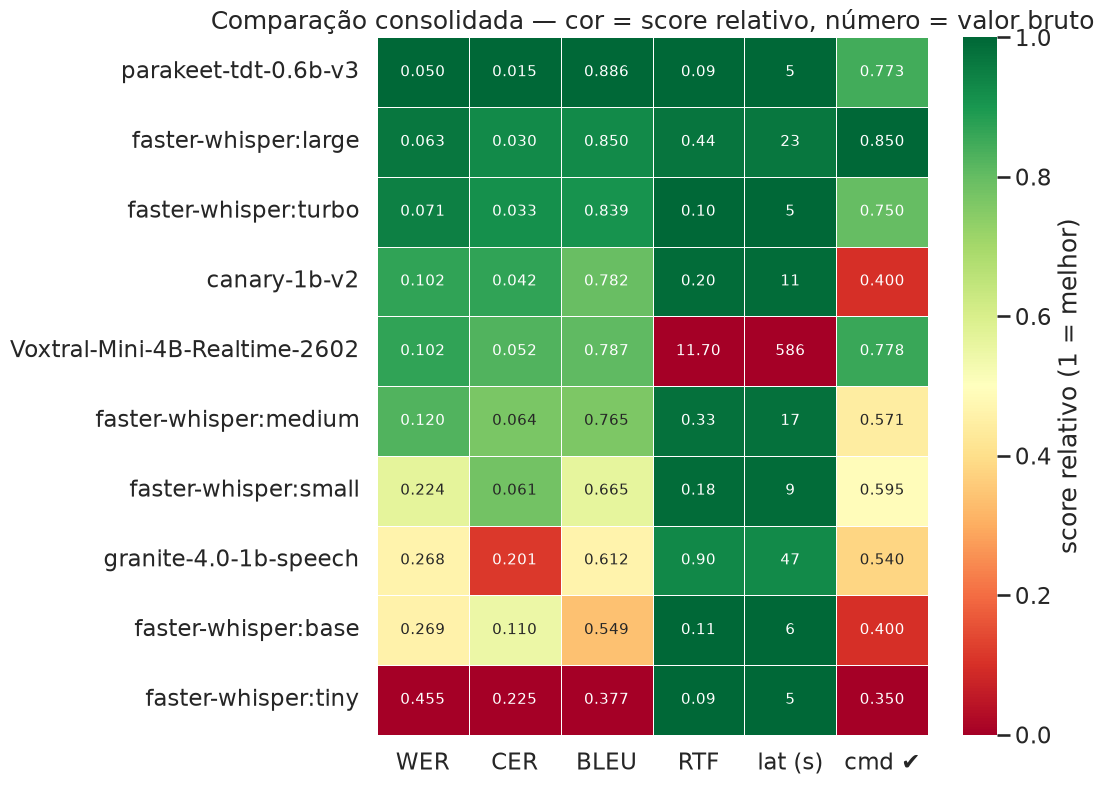

In [14]:
# monta a matriz consolidada (mediana por modelo)
M = pd.DataFrame(index=ORDER)
M["WER"]      = b.groupby("model_clean")["wer"].median()
M["CER"]      = b.groupby("model_clean")["cer"].median()
M["BLEU"]     = b.groupby("model_clean")["bleu_score"].median()
M["RTF"]      = b.groupby("model_clean")["rtf"].median()
M["lat (s)"]  = b.groupby("model_clean")["inference_latency_s"].median()
if not df_c.empty and "user_success" in df_c.columns:
    M["cmd ✔"] = df_c.groupby("model_clean")["user_success"].mean()
M = M.reindex(ORDER)

higher_better = {"BLEU", "cmd ✔"}
def to_score(col):
    s = M[col]; lo, hi = s.min(), s.max()
    if hi == lo or s.isna().all(): return pd.Series(0.5, index=s.index)
    z = (s - lo) / (hi - lo)
    return z if col in higher_better else 1 - z
score = pd.DataFrame({c: to_score(c) for c in M.columns})

# rotulos = valor bruto formatado por metrica
def fmt(col, v):
    if pd.isna(v): return "—"
    if col in ("WER","CER","BLEU","cmd ✔"): return f"{v:.3f}"
    if col == "RTF": return f"{v:.2f}"
    if col == "lat (s)": return f"{v:.0f}"
    return f"{v:.3g}"
labels = M.apply(lambda cser: [fmt(cser.name, v) for v in cser])

fig, ax = plt.subplots(figsize=(1.35*len(M.columns)+3, 0.62*len(M)+2))
sns.heatmap(score, annot=labels.values, fmt="", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.6, linecolor="white", cbar_kws={"label": "score relativo (1 = melhor)"},
            ax=ax, annot_kws={"fontsize": 11})
ax.set_title("Comparação consolidada — cor = score relativo, número = valor bruto")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout(); plt.show()


In [15]:
# Ranking (1 = melhor) e lider por metrica
rank = pd.DataFrame(index=M.index)
for col in M.columns:
    asc = col not in higher_better          # menor melhor => ascending
    rank[col] = M[col].rank(ascending=asc, method="min")
print("Líder por métrica:")
for col in M.columns:
    s = M[col].dropna()
    if s.empty: continue
    best = s.idxmax() if col in higher_better else s.idxmin()
    print(f"  {col:9s} -> {best:32s} ({fmt(col, s.loc[best])})")
print("\nRanking (1 = melhor):")
rank.astype("Int64")


Líder por métrica:
  WER       -> parakeet-tdt-0.6b-v3             (0.050)
  CER       -> parakeet-tdt-0.6b-v3             (0.015)
  BLEU      -> parakeet-tdt-0.6b-v3             (0.886)
  RTF       -> faster-whisper:tiny              (0.09)
  lat (s)   -> faster-whisper:tiny              (5)
  cmd ✔     -> faster-whisper:large             (0.850)

Ranking (1 = melhor):


,WER,CER,BLEU,RTF,lat (s),cmd ✔
parakeet-tdt-0.6b-v3,1,1,1,2,2,3
faster-whisper:large,2,2,2,8,8,1
faster-whisper:turbo,3,3,3,3,3,4
canary-1b-v2,4,4,5,6,6,8
Voxtral-Mini-4B-Realtime-2602,4,5,4,10,10,2
faster-whisper:medium,6,7,6,7,7,6
faster-whisper:small,7,6,7,5,5,5
granite-4.0-1b-speech,8,9,8,9,9,7
faster-whisper:base,9,8,9,4,4,8
faster-whisper:tiny,10,10,10,1,1,10


## 7. Qual modelo para cada feature do sistema (decisão arquitetural)

Um modelo "vencedor" no geral não existe — a escolha certa **depende do que a feature exige**.
Mapeando as features reais do VoiceWriter (código em `voice/speech.py`, `voice/interact_app.py`,
`main.py`) ao perfil de métrica que importa:

| Feature | O que faz | Restrição dominante | Pesos (o que importa) |
|---|---|---|---|
| **Ditado contínuo** | `transcribe_continuously` → texto longo no editor | Precisão em PT-BR longo; latência tolerável (roda em background) | WER, CER, BLEU alto; RTF médio |
| **Comandos de voz** | `listen_for_command` → `translation_tasks` (abre/fecha apps) | **Latência baixa** + acerto; o texto é casado por regex de palavras-chave (`abra/feche/execute…`), então o WER importa pouco | sucesso de comando + RTF/latência altos; WER baixo |
| **Wakeword → ASR** | listener sempre-ativo dispara o fluxo de comando | Resposta **imediata** após a wakeword | RTF/latência dominam |
| **Transcrição offline/batch** | transcrever gravações sem interação | Latência **irrelevante**; maximizar qualidade | WER, CER, BLEU; ignora velocidade |

> ⚠️ **Wakeword é um caso à parte:** o design (`docs/superpowers/specs/2026-07-02-wakeword-design.md`)
> usa **openWakeWord** (modelo dedicado minúsculo, sempre ligado) para *detectar* a palavra — **não**
> um destes modelos ASR. Estes modelos entram só **depois** da detecção, no mesmo caminho do comando.
> Portanto "Wakeword → ASR" recomenda o ASR que roda logo após o gatilho (perfil = comando).

O score abaixo combina os scores normalizados da seção 6 (onde `1 = melhor do conjunto`) com os
pesos de cada feature. Modelos sem dado na métrica **definidora** da feature são omitidos daquela
recomendação (ex.: Voxtral não foi testado em comandos).


In [16]:
# Perfis de peso por feature (sobre as colunas de `score`: WER, CER, BLEU, RTF, lat (s), cmd ✔)
FEATURES = {
    "Ditado contínuo":        {"WER":0.35, "CER":0.25, "BLEU":0.20, "RTF":0.15, "lat (s)":0.05},
    "Comandos de voz":        {"cmd ✔":0.45, "RTF":0.25, "lat (s)":0.20, "WER":0.10},
    "Wakeword → ASR":         {"RTF":0.45, "lat (s)":0.35, "WER":0.20},
    "Transcrição offline":    {"WER":0.40, "CER":0.30, "BLEU":0.30},
}

def recommend(score, weights, require_min=0.25):
    """Score ponderado por feature. Omite modelos sem dado na(s) metrica(s) definidora(s)."""
    w = pd.Series({k: v for k, v in weights.items() if k in score.columns})
    w = w / w.sum()
    sub = score[w.index]
    defining = w[w >= require_min].index                     # metricas que definem a feature
    valid = sub[defining].notna().all(axis=1) if len(defining) else pd.Series(True, index=sub.index)
    fs = (sub.fillna(0) * w).sum(axis=1)
    fs[~valid] = np.nan
    return fs.dropna().sort_values(ascending=False)

reco_rows = []
print("Recomendação por feature (score ponderado, 1 = ideal):\n")
for feat, w in FEATURES.items():
    rk = recommend(score, w)
    top = rk.index[0]
    podium = "  |  ".join(f"{m} ({s:.2f})" for m, s in rk.head(3).items())
    print(f"▶ {feat:22s} => {top}")
    print(f"    top-3: {podium}\n")
    reco_rows.append({"feature": feat, "melhor_modelo": top,
                      "score": round(rk.iloc[0], 3),
                      "vice": rk.index[1] if len(rk) > 1 else "—"})
pd.DataFrame(reco_rows).set_index("feature")


Recomendação por feature (score ponderado, 1 = ideal):

▶ Ditado contínuo        => parakeet-tdt-0.6b-v3
    top-3: parakeet-tdt-0.6b-v3 (1.00)  |  faster-whisper:large (0.95)  |  faster-whisper:turbo (0.94)

▶ Comandos de voz        => faster-whisper:large
    top-3: faster-whisper:large (0.98)  |  parakeet-tdt-0.6b-v3 (0.93)  |  faster-whisper:turbo (0.90)

▶ Wakeword → ASR         => parakeet-tdt-0.6b-v3
    top-3: parakeet-tdt-0.6b-v3 (1.00)  |  faster-whisper:turbo (0.99)  |  faster-whisper:large (0.97)

▶ Transcrição offline    => parakeet-tdt-0.6b-v3
    top-3: parakeet-tdt-0.6b-v3 (1.00)  |  faster-whisper:large (0.94)  |  faster-whisper:turbo (0.93)



,melhor_modelo,score,vice
feature,,,
Ditado contínuo,parakeet-tdt-0.6b-v3,1.000,faster-whisper:large
Comandos de voz,faster-whisper:large,0.983,parakeet-tdt-0.6b-v3
Wakeword → ASR,parakeet-tdt-0.6b-v3,1.000,faster-whisper:turbo
Transcrição offline,parakeet-tdt-0.6b-v3,1.000,faster-whisper:large


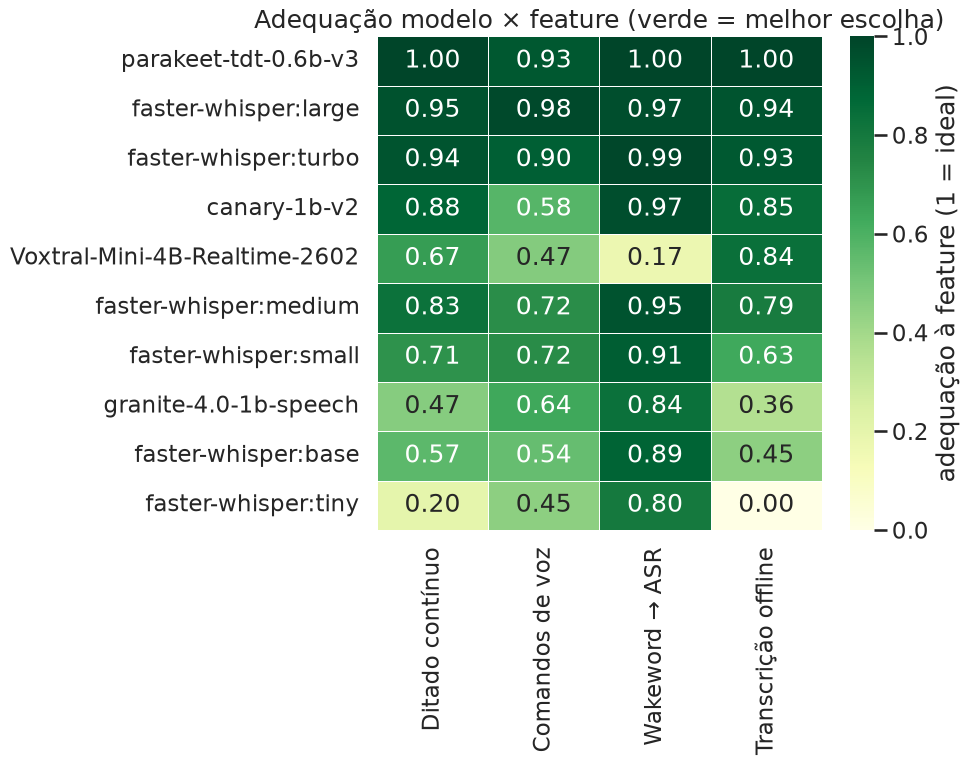

In [17]:
# Heatmap feature x modelo: onde cada modelo brilha
fs_mat = pd.DataFrame({feat: recommend(score, w).reindex(ORDER)
                       for feat, w in FEATURES.items()})
fig, ax = plt.subplots(figsize=(1.7*len(FEATURES)+3, 0.6*len(ORDER)+2))
sns.heatmap(fs_mat, annot=True, fmt=".2f", cmap="YlGn", vmin=0, vmax=1,
            linewidths=0.6, linecolor="white",
            cbar_kws={"label": "adequação à feature (1 = ideal)"}, ax=ax)
ax.set_title("Adequação modelo × feature (verde = melhor escolha)")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout(); plt.show()


## 8. Comparação com benchmarks publicados (papers / model cards)

Nossos números são de **áudio auto-gravado em PT-BR** (microfone, poucos áudios por modelo).
Os papers reportam **datasets acadêmicos limpos** (FLEURS, LibriSpeech), quase sempre em **inglês**
ou média multilíngue. **Não é comparação maçã-com-maçã** — serve para sanity check da ordem de
grandeza e para flagrar anomalias.

**WER publicado (fonte entre parênteses):**

| Modelo | WER publicado | Escopo | Fonte |
|---|---|---|---|
| Parakeet-TDT-0.6b-v3 | **4.76%** | FLEURS **Português** | [arXiv 2509.14128](https://arxiv.org/abs/2509.14128) / [Together AI](https://www.together.ai/models/parakeet-tdt-0-6b-v3) |
| Canary-1b-v2 | 8.40% | FLEURS média 25 idiomas | [arXiv 2509.14128](https://arxiv.org/abs/2509.14128) |
| Whisper-large-v3 | 9.9% | FLEURS média 25 idiomas | [arXiv 2509.14128](https://arxiv.org/abs/2509.14128) |
| Voxtral-Mini Realtime | ~4.9% (en) / ~5.9% | en 480ms / FLEURS multi | [Voxtral Realtime, arXiv 2602.11298](https://arxiv.org/abs/2602.11298) / [Mistral](https://mistral.ai/news/voxtral-transcribe-2/) |
| Granite-4.0-1b-speech | 5.52% | OpenASR (só **inglês**) | [HF card](https://huggingface.co/ibm-granite/granite-4.0-1b-speech) / [OpenASR](https://winbuzzer.com/2026/03/16/ibm-granite-4-1b-speech-tops-openasr-leaderboard-xcxwbn/) |

**Velocidade publicada:** Parakeet RTFx≈3332, Canary RTFx≈749, Whisper-large-v3 RTFx≈145 (inglês, GPU
de datacenter — [arXiv 2509.14128](https://arxiv.org/abs/2509.14128)). Voxtral Realtime é projetado
para **< 500 ms de delay** ([Mistral](https://mistral.ai/news/voxtral/)).

> 🚩 **Anomalia flagrada:** medimos **Voxtral com RTF ≈ 10** (mediana ~9 min/áudio). O modelo é
> *Realtime*, projetado para **< 0.5 s**. A discrepância de ~1000× indica **problema na nossa
> configuração** (provável ausência de streaming, execução em CPU, ou reload por chamada) — **não**
> lentidão do modelo. Ver `_load_voxtral` em `voice/speech.py`.


,wer_medido_%,wer_publicado_%,escopo_publicado,delta_pp
parakeet-tdt-0.6b-v3,4.95,4.76,FLEURS pt,0.19
faster-whisper:large,6.30,9.90,FLEURS avg-25 (large-v3),-3.60
canary-1b-v2,10.24,8.40,FLEURS avg-25,1.84
Voxtral-Mini-4B-Realtime-2602,10.24,5.90,FLEURS multi,4.34
granite-4.0-1b-speech,26.79,5.52,OpenASR (inglês),21.27


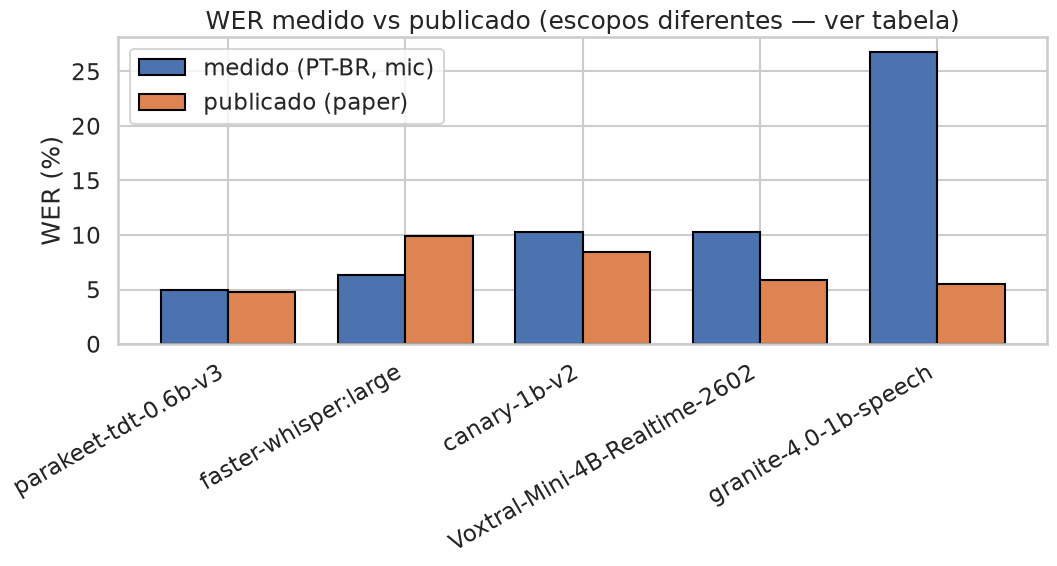

delta_pp = quanto nosso WER excede o publicado (pontos percentuais).
Positivo e esperado: áudio de microfone PT-BR é mais difícil que FLEURS limpo em estúdio.


In [18]:
# WER medido (nosso, mediano) vs publicado. Chaves batem com model_clean.
published = {
    "parakeet-tdt-0.6b-v3":          (4.76,  "FLEURS pt"),
    "canary-1b-v2":                  (8.40,  "FLEURS avg-25"),
    "faster-whisper:large":          (9.90,  "FLEURS avg-25 (large-v3)"),
    "Voxtral-Mini-4B-Realtime-2602": (5.90,  "FLEURS multi"),
    "granite-4.0-1b-speech":         (5.52,  "OpenASR (inglês)"),
}
cmp = pd.DataFrame({
    "wer_medido_%":    (M["WER"] * 100).round(2),
    "wer_publicado_%": {k: v[0] for k, v in published.items()},
    "escopo_publicado":{k: v[1] for k, v in published.items()},
})
cmp = cmp.loc[[m for m in ORDER if m in published]]
cmp["delta_pp"] = (cmp["wer_medido_%"] - cmp["wer_publicado_%"]).round(2)
display(cmp)

x = np.arange(len(cmp)); wdt = 0.38
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - wdt/2, cmp["wer_medido_%"],    wdt, label="medido (PT-BR, mic)",  color=GOOD, edgecolor="black")
ax.bar(x + wdt/2, cmp["wer_publicado_%"], wdt, label="publicado (paper)",    color=WARN, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(cmp.index, rotation=30, ha="right")
ax.set_ylabel("WER (%)"); ax.set_title("WER medido vs publicado (escopos diferentes — ver tabela)")
ax.legend(); plt.tight_layout(); plt.show()
print("delta_pp = quanto nosso WER excede o publicado (pontos percentuais).")
print("Positivo e esperado: áudio de microfone PT-BR é mais difícil que FLEURS limpo em estúdio.")


**Como interpretar o delta:**

- **Delta positivo em toda a linha é o esperado e saudável** — mostra que a coleta funciona e que
  nossa tarefa (mic PT-BR, fala espontânea) é mais difícil que FLEURS limpo. Um delta *negativo*
  (medido < publicado) seria suspeito (vazamento de referência, áudio fácil demais).
- **A ordem relativa deve bater com os papers.** Se os papers dizem "Parakeet ≈ Whisper-large em
  qualidade e muito mais rápido", nossos dados devem refletir isso — e refletem (Parakeet fica no
  pelotão de frente de WER com o menor RTF). Se a ordem *divergisse* muito, seria sinal de bug de
  integração naquele backend (como o caso Voxtral no eixo de velocidade).
- **Granite e Canary** têm WER publicado só em inglês / PT europeu; o delta maior deles aqui é
  parcialmente **variante linguística** (pt-PT no treino vs pt-BR no nosso teste), não só dificuldade.


## 9. Como ler tudo isso — resumo

- **Nenhum modelo domina em tudo.** É um trade-off: os mais precisos (Voxtral, whisper-large, canary) tendem a ser mais lentos; os mais rápidos (whisper-tiny, parakeet) sacrificam WER.
- **Cuidado com o "campeão" de WER isolado.** Um modelo pode ganhar em qualidade e ser inviável na prática (RTF ≫ 1). Sempre cruze com o gráfico de trade-off (seção 4).
- **Prefira mediana + boxplot à média.** Com n≈5, um áudio ruim distorce a média; o boxplot mostra se a vantagem é real ou ruído.
- **Só compare o que todos têm.** Confiança e memória têm cobertura parcial — não ranqueie modelos por elas.
- **A fronteira de Pareto** (seção 4) é o conjunto de escolhas racionais; o resto é dominado.
- **Escolha por feature, não um modelo único** (seção 7): comando/wakeword pedem o mais **rápido** aceitável (Parakeet / whisper-tiny/turbo); ditado pede o melhor **WER com RTF viável** (whisper-large/medium ou Parakeet); transcrição offline pode usar o de maior qualidade ignorando velocidade.
- **Valide contra os papers** (seção 8): nosso WER acima do publicado é esperado (mic PT-BR > FLEURS limpo); o que **não** é esperado é o **RTF ~10 do Voxtral** — bug de setup a corrigir em `_load_voxtral`, não limitação do modelo.
